# Análisis Completo de Accidentes Fatality Histórico
Este notebook carga el CSV histórico de accidentes y realiza un análisis exploratorio similar al notebook de PCI Histórico.

## 1. Importar librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Librerías cargadas correctamente')


✓ Librerías cargadas correctamente


## 2. Cargar los datos de Accidentes Fatality

In [2]:
file_path = r'../CSVS/accidentes-fatality-histo.csv'
print('Cargando archivo CSV...')
df_acc = pd.read_csv(file_path)
print('✓ Archivo cargado exitosamente')
print(f'Forma del dataset: {df_acc.shape}')
print(f'Tamaño en memoria: {df_acc.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')


Cargando archivo CSV...
✓ Archivo cargado exitosamente
Forma del dataset: (359, 28)
Tamaño en memoria: 0.39 MB


In [3]:
df_acc.head()


,unique_id,case_id_fkey,latitude,longitude,collision_year,death_date,death_time,death_datetime,collision_date,collision_time,...,in_coc_2018,publish,on_vz_hin_2022,in_epa_2021,point,analysis_neighborhood,supervisor_district,police_district,data_as_of,data_loaded_at
0,1,140236301,37.710409,-122.404226,2014,2014/03/20,11:21:00,2014/03/20 11:21:00 AM,2014/03/20,NaN,...,False,True,True,False,POINT (-122.404226037 37.710409217),Bayview Hunters Point,10.0,INGLESIDE,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
1,2,140755533,37.725476,-122.394243,2014,2014/09/08,16:38:00,2014/09/08 04:38:00 PM,2014/09/08,05:10:00,...,True,True,True,True,POINT (-122.394243493 37.72547565),Bayview Hunters Point,10.0,BAYVIEW,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
2,4,140365546,37.748255,-122.413669,2014,2014/05/03,17:20:00,2014/05/03 05:20:00 PM,2014/05/03,02:24:00,...,False,True,True,False,POINT (-122.413668844 37.748255329),Mission,9.0,MISSION,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
3,16,150562049,37.777300,-122.419694,2015,2015/06/30,06:00:00,2015/06/30 06:00:00 AM,2015/06/28,03:52:00,...,False,True,True,True,POINT (-122.419693566 37.777299856),Tenderloin,5.0,NORTHERN,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
4,17,140104811,37.778251,-122.419883,2014,2014/02/06,10:20:00,2014/02/06 10:20:00 AM,2014/02/05,02:26:00,...,False,True,True,True,POINT (-122.419883231 37.778251017),Hayes Valley,5.0,NORTHERN,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM


## 3. Información general del dataset

In [4]:
print('='*80)
print('INFORMACIÓN GENERAL DEL DATASET DE ACCIDENTES FATALITY')
print('='*80)
print(f'Número total de filas (registros): {df_acc.shape[0]:,}')
print(f'Número total de columnas: {df_acc.shape[1]}')
print(f'Tamaño en memoria: {df_acc.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')
print('\nMemoria por columna:')
for col, mem in df_acc.memory_usage(deep=True).items():
    print(f'  {col:30s}: {mem / 1024 / 1024:6.2f} MB')


INFORMACIÓN GENERAL DEL DATASET DE ACCIDENTES FATALITY
Número total de filas (registros): 359
Número total de columnas: 28
Tamaño en memoria: 0.39 MB

Memoria por columna:
  Index                         :   0.00 MB
  unique_id                     :   0.00 MB
  case_id_fkey                  :   0.02 MB
  latitude                      :   0.00 MB
  longitude                     :   0.00 MB
  collision_year                :   0.00 MB
  death_date                    :   0.02 MB
  death_time                    :   0.02 MB
  death_datetime                :   0.02 MB
  collision_date                :   0.02 MB
  collision_time                :   0.02 MB
  collision_datetime            :   0.02 MB
  location                      :   0.03 MB
  age                           :   0.00 MB
  sex                           :   0.02 MB
  deceased                      :   0.02 MB
  collision_type                :   0.03 MB
  street_type                   :   0.02 MB
  on_vz_hin_2017                :   

## 4. Columnas y tipos de datos

In [5]:
print('\n' + '='*80)
print('COLUMNAS DEL DATASET DE ACCIDENTES')
print('='*80)
for i, col in enumerate(df_acc.columns, 1):
    print(f'{i:2d}. {col}')
print('\n' + '='*80)
print('TIPOS DE DATOS')
print('='*80)
print(df_acc.dtypes)



COLUMNAS DEL DATASET DE ACCIDENTES
 1. unique_id
 2. case_id_fkey
 3. latitude
 4. longitude
 5. collision_year
 6. death_date
 7. death_time
 8. death_datetime
 9. collision_date
10. collision_time
11. collision_datetime
12. location
13. age
14. sex
15. deceased
16. collision_type
17. street_type
18. on_vz_hin_2017
19. in_coc_2018
20. publish
21. on_vz_hin_2022
22. in_epa_2021
23. point
24. analysis_neighborhood
25. supervisor_district
26. police_district
27. data_as_of
28. data_loaded_at

TIPOS DE DATOS
unique_id                  int64
case_id_fkey                 str
latitude                 float64
longitude                float64
collision_year             int64
death_date                   str
death_time                   str
death_datetime               str
collision_date               str
collision_time               str
collision_datetime           str
location                     str
age                      float64
sex                          str
deceased                  

## 5. Análisis de valores nulos

In [6]:
null_analysis = pd.DataFrame({
    'Columna': df_acc.columns,
    'Valores Nulos': df_acc.isnull().sum().values,
    'Porcentaje (%)': (df_acc.isnull().sum().values / len(df_acc) * 100).round(2),
    'Valores Válidos': df_acc.notna().sum().values
})
print(null_analysis.to_string(index=False))
print(f'\nTOTAL de valores nulos en el dataset: {df_acc.isnull().sum().sum():,}')
print(f'Porcentaje total: {(df_acc.isnull().sum().sum() / (df_acc.shape[0] * df_acc.shape[1]) * 100):.2f}%')


              Columna  Valores Nulos  Porcentaje (%)  Valores Válidos
            unique_id              0            0.00              359
         case_id_fkey              7            1.95              352
             latitude              0            0.00              359
            longitude              0            0.00              359
       collision_year              0            0.00              359
           death_date              0            0.00              359
           death_time             36           10.03              323
       death_datetime              0            0.00              359
       collision_date              0            0.00              359
       collision_time             25            6.96              334
   collision_datetime              0            0.00              359
             location              0            0.00              359
                  age              1            0.28              358
                  se

## 6. Conversión de fechas y análisis temporal

In [7]:
df_acc['collision_date'] = pd.to_datetime(df_acc['collision_date'], errors='coerce')
df_acc['collision_datetime'] = pd.to_datetime(df_acc['collision_datetime'], errors='coerce')
df_acc['death_datetime'] = pd.to_datetime(df_acc['death_datetime'], errors='coerce')
df_acc['collision_year'] = pd.to_numeric(df_acc['collision_year'], errors='coerce').astype('Int64')
df_acc['collision_month'] = df_acc['collision_date'].dt.month
print('Fechas convertidas correctamente')
print(f'Registros con fecha de colisión válida: {df_acc["collision_date"].notna().sum():,}')
print(f'Registros con fecha de colisión inválida: {df_acc["collision_date"].isna().sum():,}')


Fechas convertidas correctamente
Registros con fecha de colisión válida: 359
Registros con fecha de colisión inválida: 0


## 7. Distribución por año y por mes

In [8]:
yearly_counts = df_acc['collision_year'].value_counts().sort_index()
monthly_counts = df_acc['collision_month'].value_counts().sort_index()
print('Registros por año de colisión:')
print(yearly_counts)
print('\nRegistros por mes de colisión:')
print(monthly_counts)


Registros por año de colisión:
collision_year
2014    30
2015    31
2016    29
2017    20
2018    23
2019    29
2020    30
2021    27
2022    39
2023    26
2024    42
2025    25
2026     8
Name: count, dtype: Int64

Registros por mes de colisión:
collision_month
1     24
2     27
3     43
4     17
5     34
6     31
7     25
8     33
9     30
10    32
11    28
12    35
Name: count, dtype: int64


## 8. Análisis de variables categóricas

In [9]:
categorical_columns = [
    'sex', 'deceased', 'collision_type', 'street_type',
    'analysis_neighborhood', 'supervisor_district', 'police_district'
]
for col in categorical_columns:
    if col in df_acc.columns:
        counts = df_acc[col].value_counts(dropna=False)
        pct = (df_acc[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        summary = pd.DataFrame({
            'Valor': counts.index.astype(str),
            'Cantidad': counts.values,
            'Porcentaje': pct.values
        })
        print('\n' + '='*60)
        print(f'Columna: {col}')
        print('='*60)
        print(summary.head(20).to_string(index=False))



Columna: sex
 Valor  Cantidad  Porcentaje
  Male       253       70.47
Female       106       29.53

Columna: deceased
                       Valor  Cantidad  Porcentaje
                  Pedestrian       211       58.77
                Motorcyclist        48       13.37
                      Driver        42       11.70
                   Bicyclist        25        6.96
                   Passenger        18        5.01
Standup Powered Device Rider        10        2.79
          Exterior Passenger         3        0.84
                       Moped         2        0.56

Columna: collision_type
                                 Valor  Cantidad  Porcentaje
           Pedestrian vs Motor Vehicle       193       53.76
               Motor Vehicle Collision        55       15.32
           Motorcycle vs Motor Vehicle        26        7.24
                  Motorcycle Collision        18        5.01
              Bicycle vs Motor Vehicle        17        4.74
        Motor Vehicle Collisio

## 9. Visualización de datos categóricos y temporales

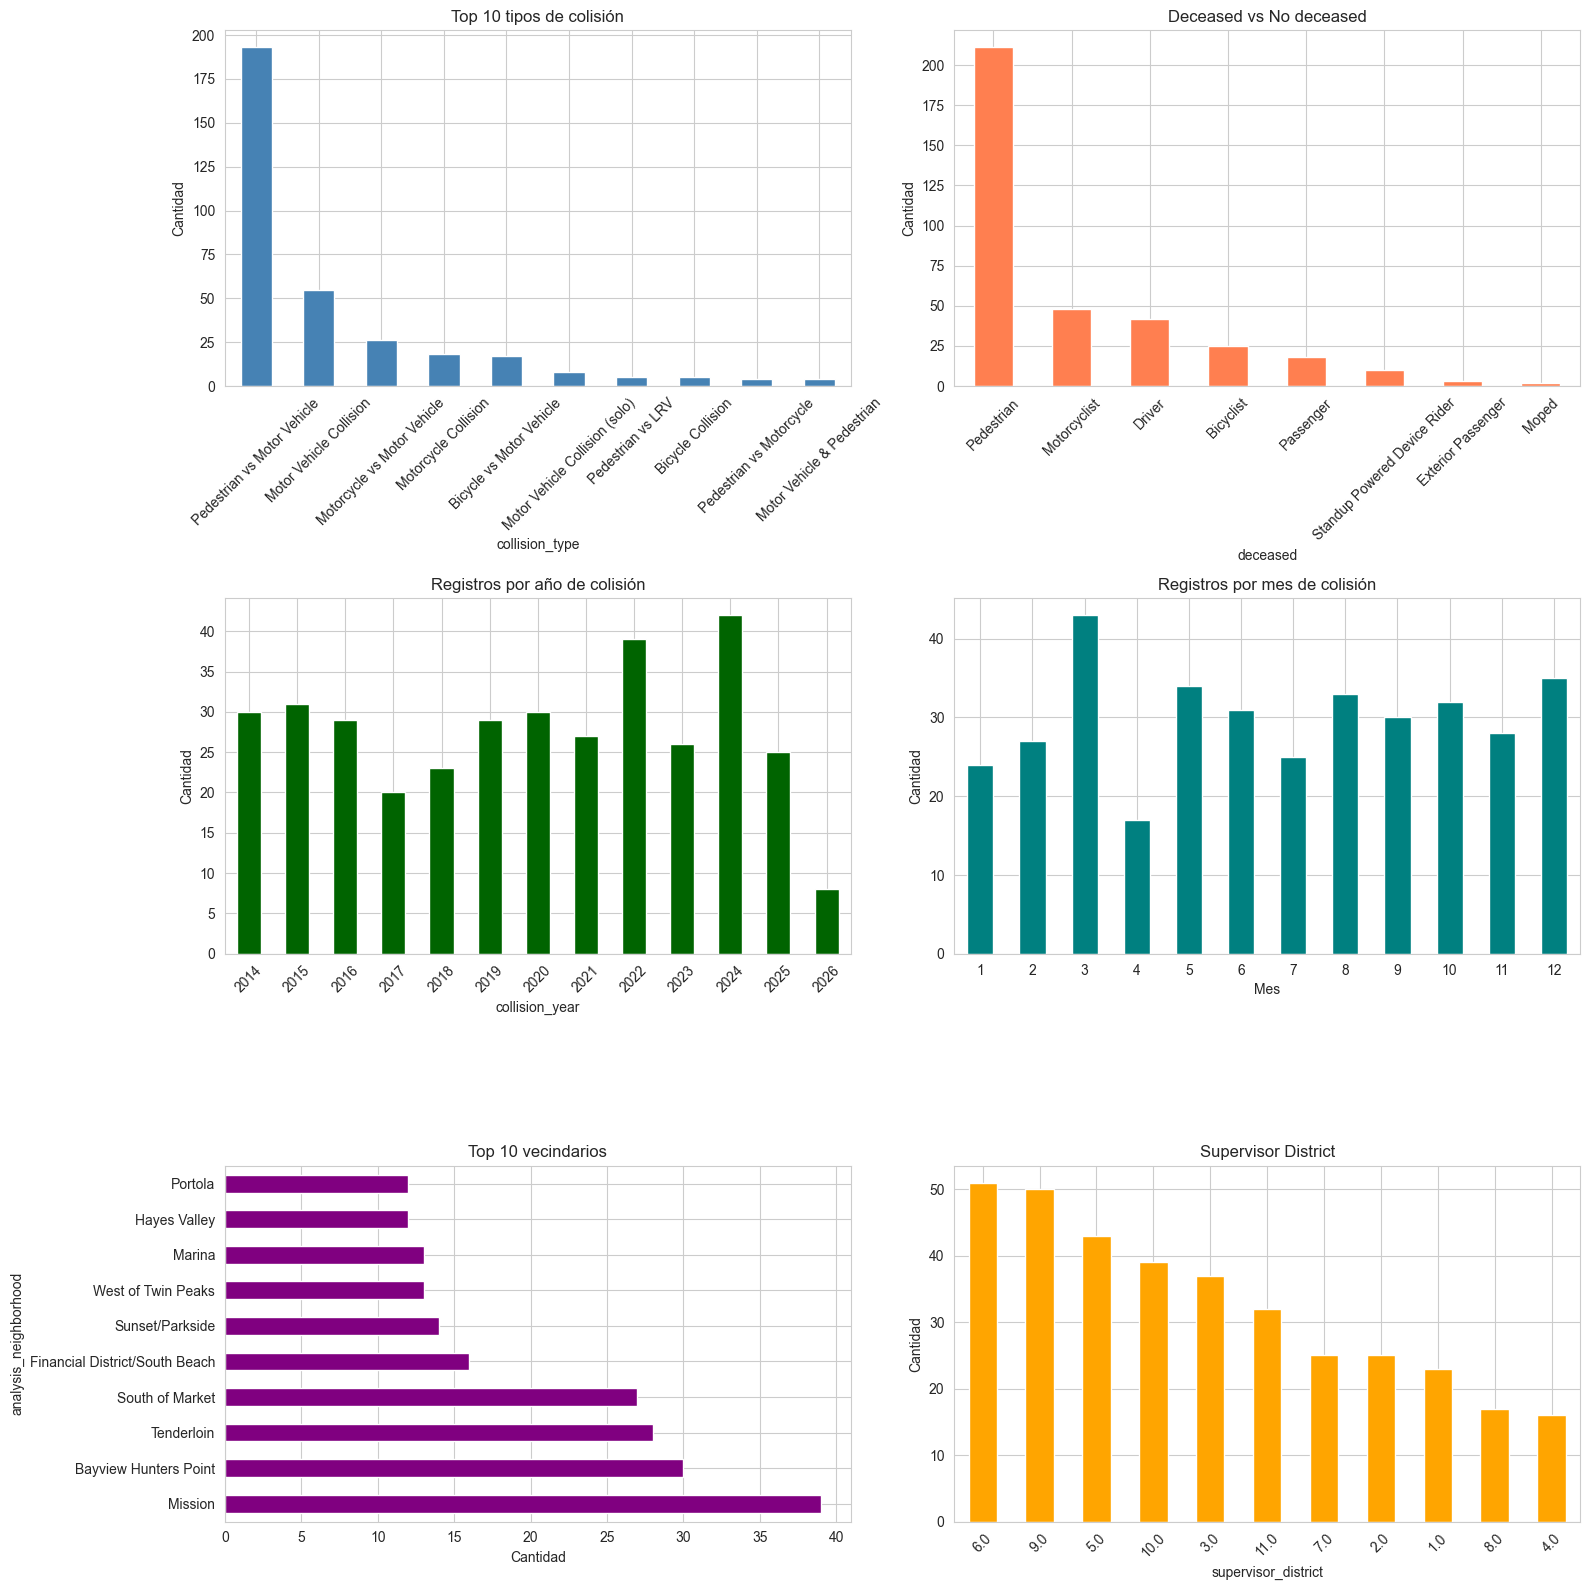

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
if 'collision_type' in df_acc.columns:
    df_acc['collision_type'].value_counts().head(10).plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Top 10 tipos de colisión')
    axes[0, 0].set_ylabel('Cantidad')
    axes[0, 0].tick_params(axis='x', rotation=45)
if 'deceased' in df_acc.columns:
    df_acc['deceased'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Deceased vs No deceased')
    axes[0, 1].set_ylabel('Cantidad')
    axes[0, 1].tick_params(axis='x', rotation=45)
if 'collision_year' in df_acc.columns:
    yearly_counts.plot(kind='bar', ax=axes[1, 0], color='darkgreen')
    axes[1, 0].set_title('Registros por año de colisión')
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].tick_params(axis='x', rotation=45)
if 'collision_month' in df_acc.columns:
    monthly_counts.plot(kind='bar', ax=axes[1, 1], color='teal')
    axes[1, 1].set_title('Registros por mes de colisión')
    axes[1, 1].set_ylabel('Cantidad')
    axes[1, 1].set_xlabel('Mes')
    axes[1, 1].tick_params(axis='x', rotation=0)
if 'analysis_neighborhood' in df_acc.columns:
    df_acc['analysis_neighborhood'].value_counts().head(10).plot(kind='barh', ax=axes[2, 0], color='purple')
    axes[2, 0].set_title('Top 10 vecindarios')
    axes[2, 0].set_xlabel('Cantidad')
if 'supervisor_district' in df_acc.columns:
    df_acc['supervisor_district'].value_counts().plot(kind='bar', ax=axes[2, 1], color='orange')
    axes[2, 1].set_title('Supervisor District')
    axes[2, 1].set_ylabel('Cantidad')
    axes[2, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 10. Análisis espacial

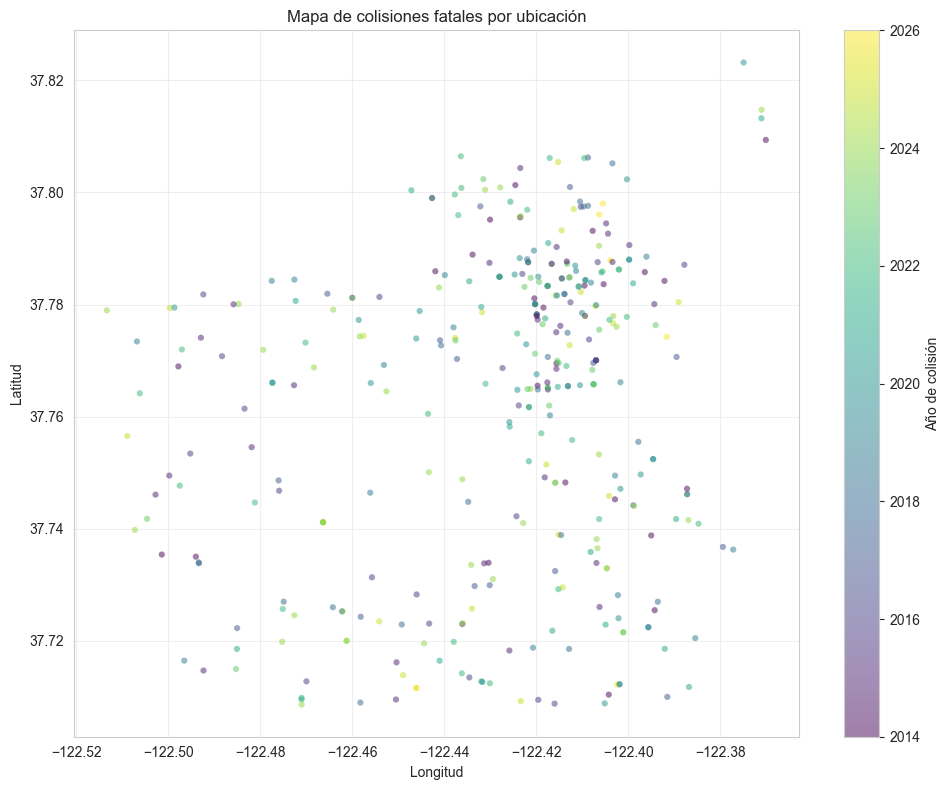

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = df_acc['latitude'].notna() & df_acc['longitude'].notna()
sc = ax.scatter(
    df_acc.loc[mask, 'longitude'],
    df_acc.loc[mask, 'latitude'],
    c=df_acc.loc[mask, 'collision_year'].fillna(0),
    cmap='viridis',
    alpha=0.5,
    s=20,
    edgecolors='none'
)
ax.set_title('Mapa de colisiones fatales por ubicación')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Año de colisión')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Detección de duplicados y registros únicos

In [12]:
print('Duplicados en unique_id:', df_acc['unique_id'].duplicated().sum())
print('Duplicados completos en filas:', df_acc.duplicated().sum())
print('Registros únicos de case_id_fkey:', df_acc['case_id_fkey'].nunique())


Duplicados en unique_id: 0
Duplicados completos en filas: 0
Registros únicos de case_id_fkey: 343


## 12. Primeras y últimas filas del dataset

In [13]:
print('Primeras 10 filas:')
print(df_acc.head(10).to_string(index=False))
print('\nÚltimas 10 filas:')
print(df_acc.tail(10).to_string(index=False))


Primeras 10 filas:
 unique_id case_id_fkey  latitude   longitude  collision_year death_date death_time      death_datetime collision_date collision_time  collision_datetime                                                   location  age    sex     deceased                 collision_type street_type  on_vz_hin_2017  in_coc_2018  publish  on_vz_hin_2022  in_epa_2021                               point analysis_neighborhood  supervisor_district police_district             data_as_of         data_loaded_at  collision_month
         1    140236301 37.710409 -122.404226            2014 2014/03/20   11:21:00 2014-03-20 11:21:00     2014-03-20            NaN 2014-03-20 00:00:00                          Bayshore Blvd near Visitation Ave 82.0 Female   Pedestrian    Pedestrian vs Motor Vehicle City Street           False        False     True            True        False POINT (-122.404226037 37.710409217) Bayview Hunters Point                 10.0       INGLESIDE 2024/09/18 12:00:00 AM 2026/05/0